# EGX Volatility Forecasting

In [1]:
# Environment diagnostics
import sys
print(f"Python version: {sys.version}")
print()
for pkg in ["pyspark", "pandas", "numpy", "matplotlib"]:
    try:
        mod = __import__(pkg)
        print(f"  {pkg:12s}  {mod.__version__}")
    except ImportError:
        print(f"  {pkg:12s}  NOT INSTALLED")

Python version: 3.11.6 | packaged by conda-forge | (main, Oct  3 2023, 10:40:35) [GCC 12.3.0]

  pyspark       3.5.0
  pandas        2.0.3
  numpy         1.24.4
  matplotlib    3.8.0


In [2]:
!pip install -q torch matplotlib seaborn
print("Done")

Done



## Spark session and HDFS paths


In [3]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("EGX_Volatility_Pipeline")
    .config("spark.sql.session.timeZone", "UTC")
    .config("spark.driver.memory", "3g")
    .config("spark.executor.memory", "2g")
    .config("spark.sql.shuffle.partitions", "16")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

In [4]:
HDFS_RAW      = "hdfs://namenode:9000/egx/raw"
HDFS_CLEAN    = "hdfs://namenode:9000/egx/clean_panel.parquet"
HDFS_FEATURES = "hdfs://namenode:9000/egx/feature_panel.parquet"

## File manifest



In [5]:
MANIFEST = {
    #   Indices  
    "EGX30.csv":   ("EGX30",   "index",     None),
    "EGX70.csv":   ("EGX70",   "index",     None),
    "EGX100.csv":  ("EGX100",  "index",     None),

    #   Banking & Financial Services  
    "COMI.csv":    ("COMI",  "equity", "banking"),
    "HRHO.csv":    ("HRHO",  "equity", "banking"),
    "ADIB.csv":    ("ADIB",  "equity", "banking"),
    "HDBK.csv":    ("HDBK",  "equity", "banking"),
    "CIEB.csv":    ("CIEB",  "equity", "banking"),
    "BTFH.csv":    ("BTFH",  "equity", "banking"),

    #   Telecom & Tech  
    "ETEL.csv":    ("ETEL",  "equity", "telecom_tech"),
    "FWRY.csv":    ("FWRY",  "equity", "telecom_tech"),
    "EFIH.csv":    ("EFIH",  "equity", "telecom_tech"),
    "RAYA.csv":    ("RAYA",  "equity", "telecom_tech"),

    #   Real Estate  
    "TMGH.csv":    ("TMGH",  "equity", "real_estate"),
    "PHDC.csv":    ("PHDC",  "equity", "real_estate"),
    "HELI.csv":    ("HELI",  "equity", "real_estate"),
    "MNHD.csv":    ("MNHD",  "equity", "real_estate"),
    "EMFD.csv":    ("EMFD",  "equity", "real_estate"),
    "OCDI.csv":    ("OCDI",  "equity", "real_estate"),

    #   Industrials & Construction  
    "ORAS.csv":    ("ORAS",  "equity", "industrials"),
    "SWDY.csv":    ("SWDY",  "equity", "industrials"),
    "AUTO.csv":    ("AUTO",  "equity", "industrials"),

    #   Consumer Goods  
    "EAST.csv":    ("EAST",  "equity", "consumer"),
    "JUFO.csv":    ("JUFO",  "equity", "consumer"),
    "EFID.csv":    ("EFID",  "equity", "consumer"),
    "ORWE.csv":    ("ORWE",  "equity", "consumer"),
    "POUL.csv":    ("POUL",  "equity", "consumer"),

    #   Energy & Materials  
    "ABUK.csv":    ("ABUK",  "equity", "energy_materials"),
    "SKPC.csv":    ("SKPC",  "equity", "energy_materials"),
    "AMOC.csv":    ("AMOC",  "equity", "energy_materials"),
    "EGCH.csv":    ("EGCH",  "equity", "energy_materials"),
    "MFPC.csv":    ("MFPC",  "equity", "energy_materials"),
    "EGAL.csv":    ("EGAL",  "equity", "energy_materials"),

    #   Tourism & Healthcare  
    "ORHD.csv":    ("ORHD",  "equity", "tourism_health"),
    "ISPH.csv":    ("ISPH",  "equity", "tourism_health"),
    "PHAR.csv":    ("PHAR",  "equity", "tourism_health"),

    #   Macro & Benchmark  
    "USDEGP.csv":  ("USDEGP","fx",        None),
    "BRENT.csv":   ("BRENT", "commodity", None),
    "EEM.csv":     ("EEM",   "etf",       None),
}

print(f"Manifest contains {len(MANIFEST)} files")
print(f"  Indices:     {sum(1 for v in MANIFEST.values() if v[1] == 'index')}")
print(f"  Equities:    {sum(1 for v in MANIFEST.values() if v[1] == 'equity')}")
print(f"  FX:          {sum(1 for v in MANIFEST.values() if v[1] == 'fx')}")
print(f"  Commodities: {sum(1 for v in MANIFEST.values() if v[1] == 'commodity')}")
print(f"  ETFs:        {sum(1 for v in MANIFEST.values() if v[1] == 'etf')}")


Manifest contains 39 files
  Indices:     3
  Equities:    33
  FX:          1
  Commodities: 1
  ETFs:        1



## Ingestion


In [6]:
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, StringType

# All columns read as strings first then we parse them later
RAW_SCHEMA = StructType([
    StructField("Date",     StringType(), True),
    StructField("Price",    StringType(), True),
    StructField("Open",     StringType(), True),
    StructField("High",     StringType(), True),
    StructField("Low",      StringType(), True),
    StructField("Vol.",     StringType(), True),
    StructField("Change %", StringType(), True),
])

def read_one(filename, ticker, asset_class, sector):
    path = f"{HDFS_RAW}/{filename}"
    df = (spark.read
          .option("header", "true")
          .option("encoding", "UTF-8")
          .option("quote", '"')
          .schema(RAW_SCHEMA)
          .csv(path))
    return (df
            .withColumn("ticker",      F.lit(ticker))
            .withColumn("asset_class", F.lit(asset_class))
            .withColumn("sector",      F.lit(sector)))

# Read and union all files
dfs = [read_one(fname, t, ac, s) for fname, (t, ac, s) in MANIFEST.items()]
raw = dfs[0]
for df in dfs[1:]:
    raw = raw.unionByName(df)

raw.cache()
print(f"Total rows ingested: {raw.count():,}")
raw.show(5, truncate=False)

Total rows ingested: 138,281
+----------+---------+---------+---------+---------+-------+--------+------+-----------+------+
|Date      |Price    |Open     |High     |Low      |Vol.   |Change %|ticker|asset_class|sector|
+----------+---------+---------+---------+---------+-------+--------+------+-----------+------+
|05/05/2026|52,535.88|51,973.50|52,547.35|51,368.00|362.42M|1.08%   |EGX30 |index      |NULL  |
|05/04/2026|51,973.50|52,312.70|52,704.76|51,818.87|692.00M|-0.65%  |EGX30 |index      |NULL  |
|05/03/2026|52,312.70|51,760.97|52,393.85|51,818.92|700.54M|1.07%   |EGX30 |index      |NULL  |
|04/30/2026|51,760.97|52,383.13|52,538.84|51,748.64|637.54M|-1.19%  |EGX30 |index      |NULL  |
|04/29/2026|52,383.13|52,230.61|52,431.85|52,096.15|420.47M|0.29%   |EGX30 |index      |NULL  |
+----------+---------+---------+---------+---------+-------+--------+------+-----------+------+
only showing top 5 rows



In [7]:
print("Rows per ticker:")
raw.groupBy("ticker", "asset_class").count().orderBy(F.desc("count")).show(50, False)

Rows per ticker:
+------+-----------+-----+
|ticker|asset_class|count|
+------+-----------+-----+
|USDEGP|fx         |5898 |
|BRENT |commodity  |4219 |
|EEM   |etf        |4140 |
|EGX100|index      |3944 |
|ETEL  |equity     |3944 |
|TMGH  |equity     |3944 |
|SKPC  |equity     |3944 |
|EGX30 |index      |3943 |
|COMI  |equity     |3943 |
|PHDC  |equity     |3943 |
|AMOC  |equity     |3943 |
|HRHO  |equity     |3942 |
|OCDI  |equity     |3942 |
|HELI  |equity     |3941 |
|ADIB  |equity     |3939 |
|MNHD  |equity     |3939 |
|EGCH  |equity     |3937 |
|ORWE  |equity     |3926 |
|SWDY  |equity     |3925 |
|HDBK  |equity     |3886 |
|RAYA  |equity     |3877 |
|POUL  |equity     |3867 |
|CIEB  |equity     |3831 |
|AUTO  |equity     |3814 |
|JUFO  |equity     |3774 |
|ABUK  |equity     |3733 |
|EGAL  |equity     |3703 |
|EAST  |equity     |3689 |
|BTFH  |equity     |3408 |
|PHAR  |equity     |3394 |
|ORHD  |equity     |2708 |
|ORAS  |equity     |2703 |
|EMFD  |equity     |2634 |
|EFID  |equ

## Preprocessing


In [8]:
from pyspark.sql.window import Window

def parse_volume(col):
    c = F.trim(col)
    digits = F.regexp_replace(F.regexp_replace(c, ",", ""), "[KMB]$", "").cast("double")
    return (F.when(c.isNull() | (c == ""), None)
             .when(c.endswith("K"), digits * 1e3)
             .when(c.endswith("M"), digits * 1e6)
             .when(c.endswith("B"), digits * 1e9)
             .otherwise(digits))

# parse columns
parsed = (raw
    .withColumn("date",       F.to_date("Date", "MM/dd/yyyy"))
    .withColumn("price",      F.regexp_replace("Price", ",", "").cast("double"))
    .withColumn("open_p",     F.regexp_replace("Open",  ",", "").cast("double"))
    .withColumn("high",       F.regexp_replace("High",  ",", "").cast("double"))
    .withColumn("low",        F.regexp_replace("Low",   ",", "").cast("double"))
    .withColumn("volume",     parse_volume(F.col("`Vol.`")))
    .withColumn("change_pct", F.regexp_replace(F.col("`Change %`"), "%", "").cast("double") / 100.0)
    .select("ticker", "asset_class", "sector",
            "date", "price", "open_p", "high", "low", "volume", "change_pct")
    .filter(F.col("date").isNotNull() & F.col("price").isNotNull() & (F.col("price") > 0))
)

# Step 2: compute log-returns
w_lag = Window.partitionBy("ticker").orderBy("date")
clean = (parsed
    .withColumn("prev_price", F.lag(F.col("price")).over(w_lag))
    .withColumn("log_return", F.log(F.col("price") / F.col("prev_price")))
    .drop("prev_price")
    .filter(F.col("log_return").isNotNull())
)

clean.cache()
print(f"Clean panel rows: {clean.count():,}")
clean.printSchema()

Clean panel rows: 138,178
root
 |-- ticker: string (nullable = false)
 |-- asset_class: string (nullable = false)
 |-- sector: string (nullable = true)
 |-- date: date (nullable = true)
 |-- price: double (nullable = true)
 |-- open_p: double (nullable = true)
 |-- high: double (nullable = true)
 |-- low: double (nullable = true)
 |-- volume: double (nullable = true)
 |-- change_pct: double (nullable = true)
 |-- log_return: double (nullable = true)



In [9]:
# Sanity-check summary statistics
print("Summary statistics:")
clean.select("price", "log_return", "volume", "change_pct").summary().show()

print("\nDate range per asset class:")
(clean.groupBy("asset_class")
      .agg(F.min("date").alias("min_date"),
           F.max("date").alias("max_date"),
           F.count("*").alias("rows"))
      .orderBy("asset_class")
      .show(truncate=False))

Summary statistics:
+-------+-----------------+--------------------+--------------------+--------------------+
|summary|            price|          log_return|              volume|          change_pct|
+-------+-----------------+--------------------+--------------------+--------------------+
|  count|           138178|              138178|              129688|              138176|
|   mean| 575.374967633776|6.071529167191468E-4|2.6491058213404477E7|9.123921665122698E-4|
| stddev|2981.556326967231| 0.03031423688372058|1.4091498012558355E9| 0.02805697983637193|
|    min|             0.05|  -3.570360853878599|                 0.0|              -0.972|
|    25%|              3.9|-0.00961274012245...|            236100.0|             -0.0095|
|    50%|             8.05|                 0.0|           1130000.0|                 0.0|
|    75%|            25.21|0.009930568202600788|           4600000.0|                0.01|
|    max|         52719.12|    3.60021381702828|           5.0589E11| 

In [10]:
print(f"Writing clean panel to HDFS: {HDFS_CLEAN}")
clean.write.mode("overwrite").parquet(HDFS_CLEAN)
print("Done.")

# verify by reading it back
check = spark.read.parquet(HDFS_CLEAN)
print(f"Verified: {check.count():,} rows readable from {HDFS_CLEAN}")

Writing clean panel to HDFS: hdfs://namenode:9000/egx/clean_panel.parquet
Done.
Verified: 138,178 rows readable from hdfs://namenode:9000/egx/clean_panel.parquet



## Feature Engineering


In [11]:
clean = spark.read.parquet(HDFS_CLEAN)
print(f"Loaded {clean.count():,} rows from {HDFS_CLEAN}")

Loaded 138,178 rows from hdfs://namenode:9000/egx/clean_panel.parquet


In [12]:
#Lagged realized volatility
def vol_window(n):
    return Window.partitionBy("ticker").orderBy("date").rowsBetween(-(n-1), 0)

feats = (clean
    .withColumn("vol_5d",  F.stddev("log_return").over(vol_window(5)))
    .withColumn("vol_10d", F.stddev("log_return").over(vol_window(10)))
    .withColumn("vol_20d", F.stddev("log_return").over(vol_window(20)))
    .withColumn("vol_60d", F.stddev("log_return").over(vol_window(60)))
)


In [13]:
#Lagged returns and momentum
feats = (feats
    .withColumn("ret_1d",     F.lag("log_return", 1).over(w_lag))
    .withColumn("ret_5d",     F.sum("log_return").over(vol_window(5)))
    .withColumn("ret_20d",    F.sum("log_return").over(vol_window(20)))
    .withColumn("abs_ret_1d", F.abs(F.col("ret_1d")))
)


In [14]:
#Volume features
feats = (feats
    .withColumn("vol_avg_20d",  F.avg("volume").over(vol_window(20)))
    .withColumn("volume_ratio", F.col("volume") / F.col("vol_avg_20d"))
)


In [15]:
# Parkinson estimator
import math
PARKINSON_NORM = 1.0 / (2.0 * math.sqrt(math.log(2.0)))

feats = (feats
    .withColumn("parkinson_1d",
        F.when((F.col("high") > 0) & (F.col("low") > 0),
               F.lit(PARKINSON_NORM) * F.log(F.col("high") / F.col("low")))
         .otherwise(None))
    .withColumn("parkinson_20d", F.avg("parkinson_1d").over(vol_window(20)))
)

In [16]:
#Cross-asset features
def asset_vol(ticker_id, alias):
    return (clean
        .filter(F.col("ticker") == ticker_id)
        .select("date", "log_return")
        .withColumn(alias,
            F.stddev("log_return").over(
                Window.orderBy("date").rowsBetween(-19, 0)
            ))
        .select("date", alias))

usdegp_vol = asset_vol("USDEGP", "usdegp_vol_20d")
brent_vol  = asset_vol("BRENT",  "brent_vol_20d")
eem_vol    = asset_vol("EEM",    "eem_vol_20d")

feats = (feats
    .join(usdegp_vol, on="date", how="left")
    .join(brent_vol,  on="date", how="left")
    .join(eem_vol,    on="date", how="left")
)


In [17]:
#Sector aggregates
sector_vol = (feats
    .filter(F.col("asset_class") == "equity")
    .groupBy("date", "sector")
    .agg(F.avg("vol_20d").alias("sector_vol_20d"))
)
feats = feats.join(sector_vol, on=["date", "sector"], how="left")


In [18]:
#Calendar features
RAMADAN_PERIODS = [
    ("2010-08-11", "2010-09-09"),  ("2011-08-01", "2011-08-29"),
    ("2012-07-20", "2012-08-18"),  ("2013-07-09", "2013-08-07"),
    ("2014-06-28", "2014-07-27"),  ("2015-06-18", "2015-07-16"),
    ("2016-06-06", "2016-07-05"),  ("2017-05-27", "2017-06-24"),
    ("2018-05-16", "2018-06-14"),  ("2019-05-06", "2019-06-04"),
    ("2020-04-24", "2020-05-23"),  ("2021-04-13", "2021-05-12"),
    ("2022-04-02", "2022-05-01"),  ("2023-03-23", "2023-04-21"),
    ("2024-03-11", "2024-04-09"),  ("2025-03-01", "2025-03-29"),
    ("2026-02-18", "2026-03-19"),
]

ramadan_expr = F.lit(0)
for start, end in RAMADAN_PERIODS:
    ramadan_expr = F.when(
        (F.col("date") >= F.lit(start)) & (F.col("date") <= F.lit(end)),
        F.lit(1)
    ).otherwise(ramadan_expr)

feats = (feats
    .withColumn("dow",         F.dayofweek("date"))
    .withColumn("dom",         F.dayofmonth("date"))
    .withColumn("month_end",   (F.col("dom") >= 25).cast("int"))
    .withColumn("is_ramadan",  ramadan_expr)
    .drop("dom")
)


In [19]:
# Target variable
w_fwd = Window.partitionBy("ticker").orderBy("date").rowsBetween(1, 5)
feats = feats.withColumn("target_vol_5d_fwd", F.stddev("log_return").over(w_fwd))
feats = feats.filter(F.col("target_vol_5d_fwd").isNotNull())
print(f"Panel rows after adding target: {feats.count():,}")

Panel rows after adding target: 138,100


In [20]:
final = feats.filter(F.col("asset_class") == "equity")

FEATURE_COLS = [
    "vol_5d", "vol_10d", "vol_20d", "vol_60d",
    "ret_1d", "ret_5d", "ret_20d", "abs_ret_1d",
    "volume_ratio",
    "parkinson_1d", "parkinson_20d",
    "usdegp_vol_20d", "brent_vol_20d", "eem_vol_20d",
    "sector_vol_20d",
    "dow", "month_end", "is_ramadan",
]
TARGET_COL = "target_vol_5d_fwd"
ID_COLS    = ["ticker", "sector", "date"]

final = final.dropna(subset=FEATURE_COLS + [TARGET_COL])
print(f"Final equity-only feature panel: {final.count():,} rows")

final = final.select(*ID_COLS, *FEATURE_COLS, TARGET_COL)

# Write to HDFS
print(f"\nWriting feature panel to HDFS: {HDFS_FEATURES}")
final.write.mode("overwrite").parquet(HDFS_FEATURES)
print("Done.")

# Verify by reading back
check = spark.read.parquet(HDFS_FEATURES)
print(f"Verified: {check.count():,} rows readable from {HDFS_FEATURES}")

print("\nFinal panel rows by sector:")
final.groupBy("sector").count().orderBy(F.desc("count")).show(truncate=False)

Final equity-only feature panel: 88,292 rows

Writing feature panel to HDFS: hdfs://namenode:9000/egx/feature_panel.parquet
Done.
Verified: 88,292 rows readable from hdfs://namenode:9000/egx/feature_panel.parquet

Final panel rows by sector:
+----------------+-----+
|sector          |count|
+----------------+-----+
|banking         |17795|
|real_estate     |17304|
|energy_materials|16727|
|consumer        |13820|
|telecom_tech    |8174 |
|industrials     |8110 |
|tourism_health  |6362 |
+----------------+-----+



## Sanity checks


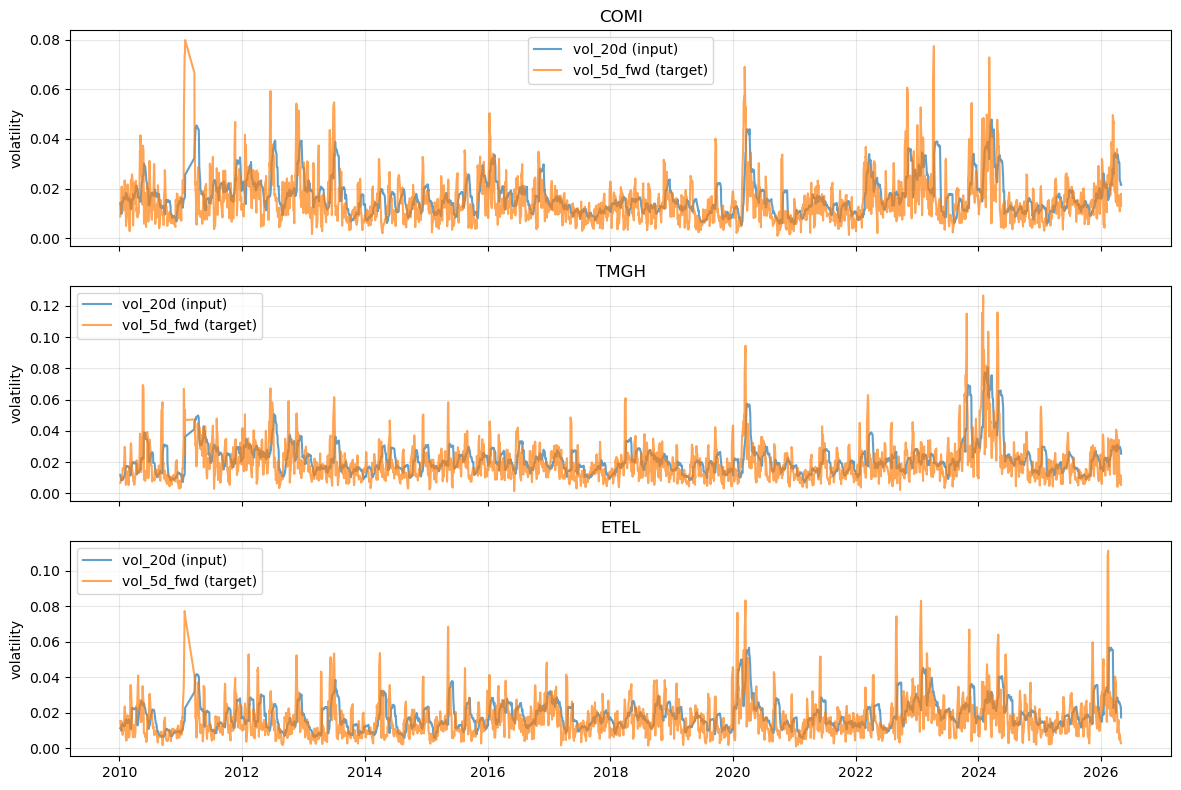

In [21]:
import os
os.makedirs("/home/jovyan/work/figs", exist_ok=True)

import matplotlib.pyplot as plt
import pandas as pd

sample = (final
    .filter(F.col("ticker").isin(["COMI", "TMGH", "ETEL"]))
    .select("ticker", "date", "vol_20d", "target_vol_5d_fwd")
    .toPandas())
sample["date"] = pd.to_datetime(sample["date"])

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax, t in zip(axes, ["COMI", "TMGH", "ETEL"]):
    s = sample[sample["ticker"] == t].sort_values("date")
    ax.plot(s["date"], s["vol_20d"], label="vol_20d (input)", alpha=0.7)
    ax.plot(s["date"], s["target_vol_5d_fwd"], label="vol_5d_fwd (target)", alpha=0.7)
    ax.set_title(t)
    ax.legend()
    ax.set_ylabel("volatility")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/home/jovyan/work/figs/sanity_volatility.png", dpi=120, bbox_inches="tight")
plt.show()

In [23]:
import numpy as np

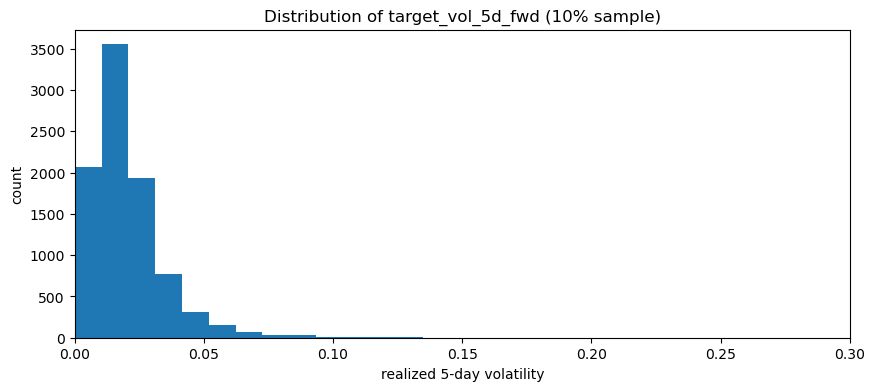

In [24]:
target_pdf = final.select("target_vol_5d_fwd").sample(0.1).toPandas()
plt.figure(figsize=(10, 4))
plt.hist(target_pdf["target_vol_5d_fwd"], bins=80)
plt.xticks(np.arange(0, target_pdf["target_vol_5d_fwd"].max() + 0.05, 0.05))
plt.xlim(0, 0.3)
plt.title("Distribution of target_vol_5d_fwd (10% sample)")
plt.xlabel("realized 5-day volatility")
plt.ylabel("count")
plt.savefig("/home/jovyan/work/figs/sanity_target_hist.png", dpi=120, bbox_inches="tight")
plt.show()